## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [ ]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [ ]:
test.shape[0]

418

In [ ]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train.shape[0]

891

In [ ]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [ ]:
test.drop(columns=['PassengerId','Cabin'],inplace=True)

In [ ]:
train.drop(columns=['PassengerId','Cabin'],inplace=True)

In [ ]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [ ]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         1
Embarked     0
dtype: int64

In [ ]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
train['Embarked'] = train['Embarked'].fillna('S')

In [ ]:
train['Embarked'].isnull().sum()

np.int64(0)

In [ ]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [ ]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [ ]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [ ]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [ ]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
dtype: int64

In [ ]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [ ]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [ ]:
print(train_Age)

[20 21 37 21 20 41 25 25 25 30 31 17 19 16 38 35 16 41 30 41 43 25 29 30
 15 20 37 35 36 26 33 26 26 33 15 43 43 29 31 22 18 43 28 33 35 42 43 27
 33 18 42 32 29 41 30 32 23 26 38 24 32 38 19 22 16 24 19 32 27 29 18 15
 29 40 41 21 43 30 34 43 23 29 15 26 25 26 35 31 25 31 21 16 40 29 24 19
 40 30 23 18 38 39 17 37 31 40 31 28 24 33 43 17 35 17 33 35 19 34 20 25
 35 23 43 37 16 22 39 26 43 30 35 24 22 36 32 32 23 24 19 40 18 27 16 17
 17 20 35 24 15 23 17 42 27 37 18 27 18 35 37 17 21 40 19 29 38 25 36 43
 22 42 34 35 40 43 36 21 21]


In [ ]:
print(test_Age)

[37 41 34 41 24 32 43 40 21 33 35 27 18 19 27 23 42 23 39 37 34 20 17 43
 34 28 18 19 25 34 26 40 30 19 20 22 19 40 22 34 30 31 35 23 26 37 32 39
 23 27 18 40 21 26 43 20 24 40 32 20 19 18 27 18 25 29 23 18 42 20 36 35
 27 27 42 26 27 16 29 31 19 23 30 18 32 30 23 34 43 21 33 20 32 38 35 34
 29 34 35 27 19 34 26 16 37 28 34 34 43 26 41 28 35 35 30 21 41 41 37 29
 24 42 25 17 19 18 42 20 17 16 25 17 43 26 30 33 16 20 36 31 33 18 34 41
 28 26 19 41 25 39 37 20 28 17 28 31 38 37 31 34 34 27 27 23 23 36 27 41
 38 26 22 25 38 31 22 20 24]


In [ ]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [ ]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [ ]:
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [ ]:
test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## EDA

In [ ]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [ ]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [ ]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [ ]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

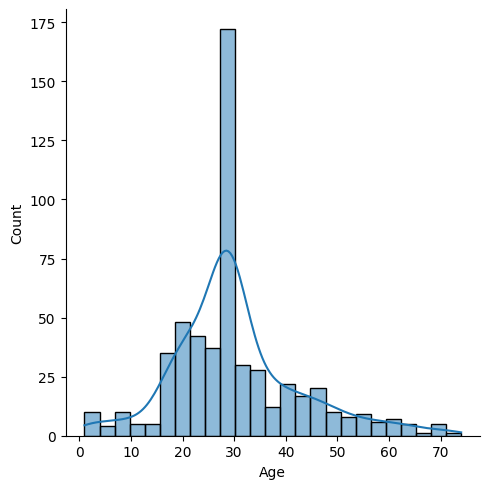

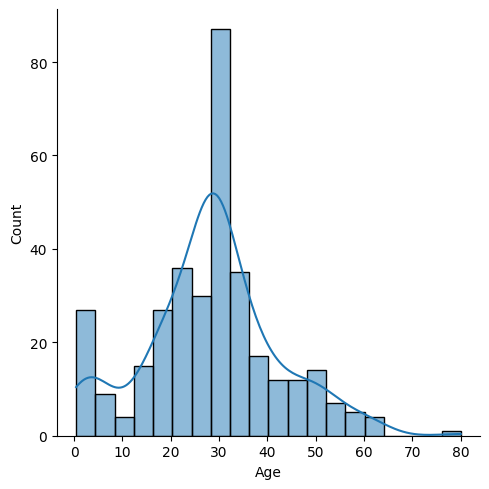

In [ ]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)